# One Pixel Attack

<br/>
<br/>
Import libraires

In [2]:
import time
import tensorflow as tf
from tensorflow import keras as k
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import softmax
from PIL import Image as im

mpl.rcParams['figure.figsize'] = (6, 6)
mpl.rcParams['axes.grid'] = False

print("everything was properly imported")

everything was properly imported


Get CIFAR-10 dataset and reshape them to use it with my network.

In [3]:
(x_train, y_train), (x_test, y_test) = k.datasets.cifar10.load_data()
class_names = ["plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

# image resolution
x_dim = 32
y_dim = 32

x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


Let's plot an image from the dataset to get a feel for how these images look.

This is an image of a cat


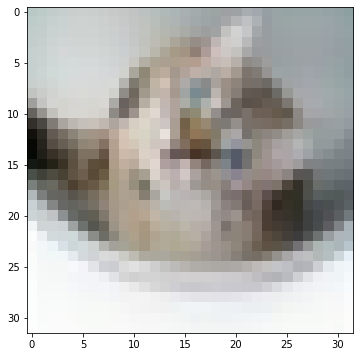

In [4]:
dataset_example = 788
print("This is an image of a", class_names[y_train[dataset_example][0]])

plt.imshow(x_train[dataset_example].reshape((x_dim, y_dim, 3)))
plt.show()

Get pre-trained convolutional neural network.

In [5]:
model = k.models.load_model("PreTrainedCNN")
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 4, 4, 64)          36928     
_________________________________________________________________
flatten (Flatten)            (None, 1024)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                6

Lets look at the network predicting some examples.

This is an image of a frog
The image is predicted to be a frog


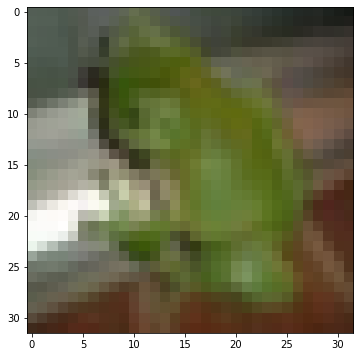

In [6]:
example = 7
prediction = model.predict_classes(np.array([x_test[example]])/255, batch_size=1)
print("This is an image of a", class_names[y_test[example][0]])
print("The image is predicted to be a", class_names[prediction[0]])
plt.imshow(x_test[example])
plt.show()

Since we're generating a lot of data and we actually want it to be random, then we should set the seed to seconds since epoch so that every time its run it'll have a different seed.

In [7]:
tf.random.set_seed(time.time())

Create function that generatates an initial population of specimens consisting of the x and y coordinates, and the rgb values for the pixel. All the values are first generated using tensorflow and then they're a normalized to the range [0,1] using min-max normalization.

In [8]:
def generate_population(amount, x_dim, y_dim):
    # generate pixel (x, y) coordinates using uniform distribution
    x = tf.random.uniform(shape=[amount, 1], minval=0, maxval=x_dim, dtype=tf.int32).numpy() # [minval, maxval)
    y = tf.random.uniform(shape=[amount, 1], minval=0, maxval=y_dim, dtype=tf.int32).numpy()

    # generate pixel rgb values using truncated normal distribution
    r = tf.random.normal(shape=[amount, 1], mean=128, stddev=127, dtype=tf.float32).numpy()
    g = tf.random.normal(shape=[amount, 1], mean=128, stddev=127, dtype=tf.float32).numpy()
    b = tf.random.normal(shape=[amount, 1], mean=128, stddev=127, dtype=tf.float32).numpy()

    # Normalization --------------------------------------
    
    # pixels range: [0, x_dim) and [0, y_dim)
    min_x = min(x)
    min_y = min(y)
    x = (x - min_x) / (max(x) - min_x)
    y = (y - min_y) / (max(y) - min_y)

    # colors range: [0, 255]
    min_r = min(r)
    min_g = min(g)
    min_b = min(b)
    r = (r - min_r) / (max(r) - min_r)
    g = (g - min_g) / (max(g) - min_g)
    b = (b - min_b) / (max(b) - min_b)

    # join all values into a numpy matrix
    population = np.hstack((x, y, r, g, b))
    
    return population

In [9]:
# amount of candidate solutions to be generated
amount = 1000

population = generate_population(amount, x_dim, y_dim)
# print(population[0])
# print(population[:,0])

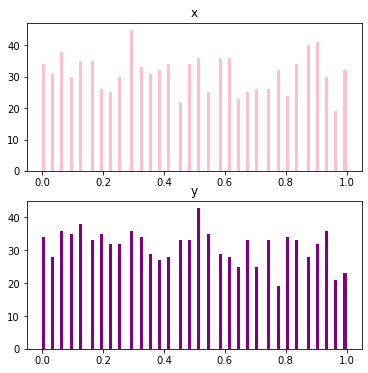

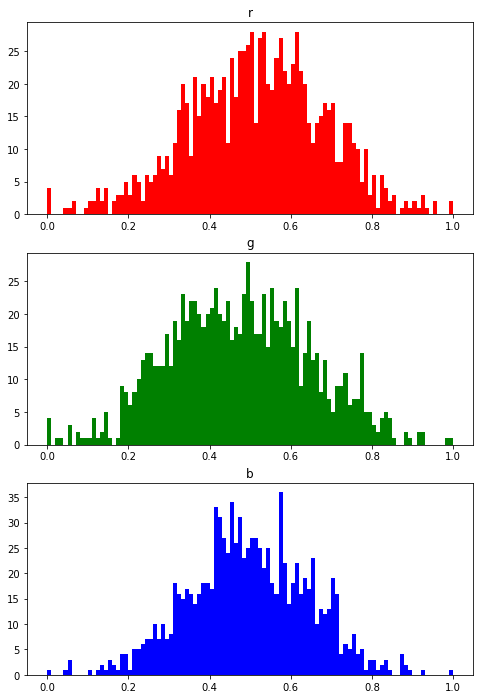

In [10]:
plt.subplot(211)
plt.title("x")
plt.hist(population[:,0], 100, color="pink")

plt.subplot(212)
plt.title("y")
plt.hist(population[:,1], 100, color="purple")

plt.show()

plt.figure(figsize=(8,12))
plt.subplot(311)
plt.title("r")
plt.hist(population[:,2], 100, color="r")

plt.subplot(312)
plt.title("g")
plt.hist(population[:,3], 100, color="g")

plt.subplot(313)
plt.title("b")
plt.hist(population[:,4], 100, color="b")

plt.show()

Functions to normalize and denormalize a single candidate

In [11]:
def normalize(candidate, x_dim, y_dim):
    x = candidate[0] / (x_dim - 1)
    y = candidate[1] / (y_dim - 1)
    r = candidate[2] / 255
    g = candidate[3] / 255
    b = candidate[4] / 255
    
    return np.hstack((x, y, r, g, b))

def denormalize(candidate, x_dim, y_dim):
    x = candidate[0] * (x_dim - 1)
    y = candidate[1] * (y_dim - 1)
    r = candidate[2] * 255
    g = candidate[3] * 255
    b = candidate[4] * 255
    
    return np.hstack((x, y, r, g, b))

In [12]:
print("original noramalized candidate:", population[0])
denorm = denormalize(population[0], x_dim, y_dim)
print("denormalized candidate:", denorm)
print("normalized candidate:", normalize(denorm, x_dim, y_dim))

original noramalized candidate: [0.09677419 0.25806452 0.36371577 0.55025589 0.41505364]
denormalized candidate: [  3.           8.          92.7475208  140.31525314 105.83867714]
normalized candidate: [0.09677419 0.25806452 0.36371577 0.55025589 0.41505364]


Function to insert a pixel into an image.

In [13]:
def insert_pixel(pixel, image):
    """pixel is a numpy array, or list, or tuple containing x, y, r, g, b; in that order
       image is a numpy array with shape (x_dim, y_dim, 3) where 3 coresponds to rgb """
    copy = np.copy(image) # copy numpy array so that we don't change the original image
    copy[int(pixel[0])][int(pixel[1])] = [pixel[2], pixel[3], pixel[4]]
    
    return copy

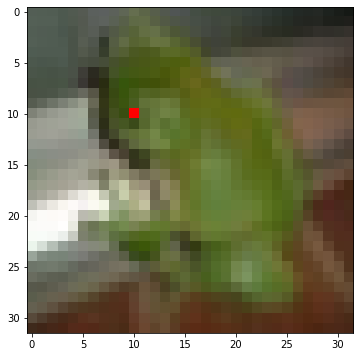

In [14]:
adversarial = insert_pixel([10, 10, 255, 0, 0], x_test[7])
plt.imshow(adversarial)
plt.show()

#### Fitness function for differential evolution
This function evaluates the efectivness of the generated adversarial pixel.
It takes the original probability distribution of the image, and compares it to the new probability distribution of the image with the adversarial pixel. It then compares the difference in confidence percentages of the predicted classes. 
- if the diference is a positive number, then the confidence percentage of the real class of the image has gone down
- if it is zero, then the confidence percentage of the real class of the image has not changed
- if it is negative, then the confidence percentage of the real class of the image has gone up

In [15]:
def fitness(network, original_probs, original_class, image, pixel):
    """ network: a keras model
        original_probs: class probability distribution of original image
        original_class: class label of the original image
        image: image being used to create a adversarial image
        pixel: candidate adversarial pixel to be tested """
    # insert adversarial pixel into image
    new_image = insert_pixel(pixel, image)
    # regularize new_image and preict its class
    new_probs = softmax(network.predict(np.array([new_image])/255, batch_size=1))[0]
    # get class label for the new image
    new_class = np.argmax(new_probs)
    # meassure change
    probability_change = original_probs[original_class] - new_probs[new_class]
    
    prediction = (new_image, new_probs, new_class)
    
    return probability_change, prediction

This is an image of a truck
The image is predicted to be a truck with a confidence of 45.58 %
After adding the pixel the model predicted it is a truck with a confidence of 52.36 %
fitness results: -0.06780958


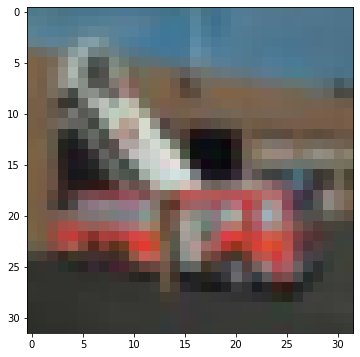

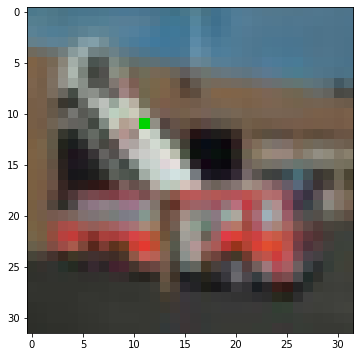

In [26]:
test_index = 3344
adv_pixel = [11, 11, 0, 210, 0]

orig_probs = softmax(model.predict(np.array([x_test[test_index]])/255, batch_size=1))[0]
orig_class = np.argmax(orig_probs)
change, pred = fitness(model, orig_probs, orig_class, x_test[test_index], adv_pixel)

print("This is an image of a", class_names[y_test[test_index][0]])
print("The image is predicted to be a", class_names[orig_class], "with a confidence of", round(orig_probs[orig_class]*100, 2), "%")
print("After adding the pixel the model predicted it is a", class_names[pred[2]], "with a confidence of", round(pred[1][pred[2]]*100, 2), "%")
print("fitness results:", change)

plt.imshow(x_test[test_index])
plt.show()

plt.imshow(pred[0])
plt.show()

#### Running Differential Evolution

In [27]:
# selecting image to generate adversarial pixels
de_index = 3344
image = x_test[de_index]
original_probs = softmax(model.predict(np.array([x_test[de_index]])/255, batch_size=1))[0]
original_class = np.argmax(orig_probs)
current_class = original_class

# initializing parameters for Differential Evolution
pop_size = 400
population = generate_population(pop_size, x_dim, y_dim)
iterations = 0
max_iters = 33
mutation_factor = 0.8
crossover = 0.5

adversarian_image = None
confidence = -1


while (original_class == current_class) and (iterations < max_iters): 
    print("starting iteration", iterations+1)
    
    max_fitness = None
    
    for i in range(pop_size):
        denorm_specimen = denormalize(population[i], x_dim, y_dim)
        original_fitness, original_results = fitness(model, original_probs, 
                                                     original_class, image, denorm_specimen)
        
        # Mutation ------------------------------------------------------------------
        # create array containing all the posible indexes except for i
        indexes = [indexes for indexes in range(pop_size) if indexes != i]
        # using that array of indexes, select 3 indexes for mutation
        breeders = np.random.choice(indexes, 3, replace=False)
        # get 3 specimens for mutation
        a, b, c = population[breeders]
        # create mutant specimen using Differential Evolution formula
        mutant = a + mutation_factor * (b - c)
        # clip values, so that values larger than 1 become 1, and values
        # smaller than 0 become 0
        mutant = np.clip(mutant, 0, 1)
        
        # Recombination -------------------------------------------------------------
        # use binomial crossover to select which part of the specimen 
        # we're inserting into population[i]
        combine = np.random.rand(5) < crossover # our specimens have 5 dimensions [x,y,r,g,b]
        new_specimen = np.where(combine, mutant, population[i])
        
        # Replacement ---------------------------------------------------------------
        # denormalize new_specimen and evaluate its fitness
        denorm_new_specimen = denormalize(new_specimen, x_dim, y_dim)
        new_fitness, new_results = fitness(model, original_probs,
                                           original_class, image, denorm_new_specimen)
        
        # keep track of specimen with the maximum fitness
        new_is_max = False
        # if new_specimen has a higher fitness than the original specimen
        if new_fitness > original_fitness:
            population[i] = new_specimen # new specimen replaces old one in the population
            new_is_max = True
            
        if i == 0: # if were at the first iteration and the variables are not initialized
            if new_is_max: # if after mutating the specimen it has a higher fitness
                max_fitness = new_fitness
                max_results = new_results
            else: # else keep the original specimen
                max_fitness = original_fitness
                max_results = original_results
        else: 
            iter_max = max(original_fitness, new_fitness)
            # if this specimen has a higher fitness than the previos max for this evolution iteration
            if max_fitness < iter_max:
                max_fitness = iter_max
                if new_is_max: # if after mutating the specimen it has a higher fitness
                    max_results = new_results
                else: # else keep the original specimen
                    max_results = original_results

                    
    adversarial_image = max_results[0]
    confidence = max_results[1]
    current_class = max_results[2]
    
    iterations += 1


if original_class != current_class:
    print("Images was originally classified as \"{}\" and now its classified as \"{}\"".format
                                                      (class_names[original_class], class_names[current_class]))

starting iteration 1
starting iteration 2
starting iteration 3
starting iteration 4
starting iteration 5
starting iteration 6
starting iteration 7
starting iteration 8
starting iteration 9
starting iteration 10
starting iteration 11
Images was originally classified as "truck" and now its classified as "bird"


The true label of the image is "truck"
The original image is predicted to be a truck with a confidence of 45.58%


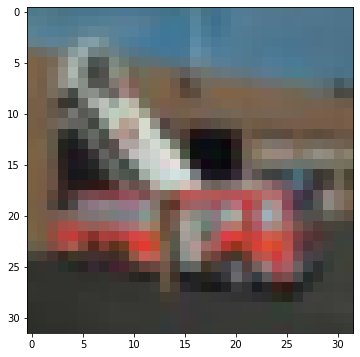

The adversarial image is predicted to be a bird with a confidence of 26.66%


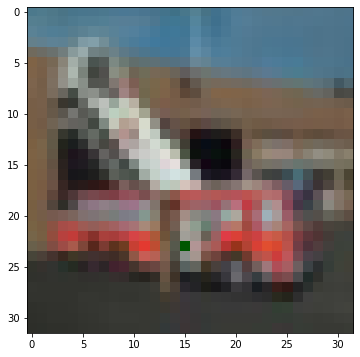

In [28]:
print("The true label of the image is \"{}\"".format(class_names[y_test[de_index][0]]))
print("The original image is predicted to be a {} with a confidence of {}%".format(class_names[original_class], round(original_probs[original_class]*100, 2)))
plt.imshow(image)
plt.show()

adv_predic = np.argmax(confidence)
print("The adversarial image is predicted to be a {} with a confidence of {}%".format(class_names[adv_predic], round(confidence[adv_predic]*100, 2)))
#print("The image actually is a {} with a confidence of {}%".format(class_names[original_class]))
plt.imshow(adversarial_image)
plt.show()

In [29]:
image_file = im.fromarray(adversarial_image)
image_file.save("./AdversarialImages/firetruck.png")